<a href="https://colab.research.google.com/github/ilfpns/PhoSem/blob/main/Phosem_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os, glob, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch: 2.11.0+cu128
CUDA: True
Device: Tesla T4


In [8]:
import os, zipfile
from google.colab import files

DATA_DIR = "/content/dataset"
os.makedirs(DATA_DIR, exist_ok=True)

uploaded = files.upload()

n_zip, n_file = 0, 0
for fname in uploaded.keys():
    if fname.lower().endswith(".zip"):
        try:
            with zipfile.ZipFile(fname, "r") as z:
                z.extractall(DATA_DIR)
            os.remove(fname)
            print(f"[zip 해제] {fname} → {DATA_DIR}")
            n_zip += 1
        except zipfile.BadZipFile:
            print(f"[오류] {fname}: 손상된 zip — 건너뜀")
    else:
        dst = os.path.join(DATA_DIR, os.path.basename(fname))
        if os.path.exists(dst):
            print(f"[덮어씀] {fname}")
        os.replace(fname, dst)
        print(f"[파일 이동] {fname} → {DATA_DIR}")
        n_file += 1

print(f"\n완료: zip {n_zip}개 해제, 일반 파일 {n_file}개 이동")
print("현재 dataset 내용물:", len(os.listdir(DATA_DIR)), "개 항목")

Saving 400-o.jpg to 400-o.jpg
Saving 400-o_die800.jpg to 400-o_die800.jpg
Saving 401-o.jpg to 401-o.jpg
Saving 401-o_die800.jpg to 401-o_die800.jpg
Saving 402-o.jpg to 402-o.jpg
Saving 402-o_die800.jpg to 402-o_die800.jpg
Saving 403-x.jpg to 403-x.jpg
Saving 403-x_die800.jpg to 403-x_die800.jpg
Saving 404-o.jpg to 404-o.jpg
Saving 404-o_die800.jpg to 404-o_die800.jpg
Saving 405-o.jpg to 405-o.jpg
Saving 405-o_die800.jpg to 405-o_die800.jpg
Saving 406-x.jpg to 406-x.jpg
Saving 406-x_die800.jpg to 406-x_die800.jpg
Saving 407-x.jpg to 407-x.jpg
Saving 407-x_die800.jpg to 407-x_die800.jpg
Saving 408-o.jpg to 408-o.jpg
Saving 408-o_die800.jpg to 408-o_die800.jpg
Saving 409-o.jpg to 409-o.jpg
Saving 409-o_die800.jpg to 409-o_die800.jpg
Saving 410-o.jpg to 410-o.jpg
Saving 410-o_die800.jpg to 410-o_die800.jpg
Saving 411-x.jpg to 411-x.jpg
Saving 411-x_die800.jpg to 411-x_die800.jpg
Saving 412-x.jpg to 412-x.jpg
Saving 412-x_die800.jpg to 412-x_die800.jpg
Saving 413-x.jpg to 413-x.jpg
Saving 4

It appears the `data_loader` module is missing. This module is expected to be part of the `Phosem-CNN-Problem-Detection` project. I will clone the GitHub repository to ensure all necessary files are available.

In [10]:
import os

repo_path = "/content/Phosem-CNN-Problem-Detection"
if not os.path.exists(repo_path):
    !git clone https://github.com/Phosem/Phosem-CNN-Problem-Detection.git {repo_path}
    print(f"Repository cloned to {repo_path}")
else:
    print(f"Repository already exists at {repo_path}")

if os.path.exists(os.path.join(repo_path, 'data_loader.py')):
    print("data_loader.py found.")
else:
    print("Error: data_loader.py not found in the cloned repository.")

Repository already exists at /content/Phosem-CNN-Problem-Detection
data_loader.py found.


In [11]:
import re

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

def parse_filename(path):
    """
    '429-x_die800.png' → {'num': 429, 'label': 'bad', 'is_die': True}
    '431-o.png'        → {'num': 431, 'label': 'good', 'is_die': False}
    규칙에 안 맞으면 None
    """
    name = os.path.splitext(os.path.basename(path))[0].lower()
    m = re.match(r"^(\d+)[-_]([ox])(.*)$", name)
    if not m:
        return None
    num, ox, rest = m.groups()
    return {
        "path": path,
        "num": int(num),
        "label": "good" if ox == "o" else "bad",
        "is_die": "die" in rest,
    }

all_files = sorted(
    p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
    if p.lower().endswith(IMG_EXTS)
)

parsed    = [info for p in all_files if (info := parse_filename(p))]
unparsed  = [p for p in all_files if parse_filename(p) is None]

die_files  = [f for f in parsed if f["is_die"]]
good_paths = sorted(f["path"] for f in die_files if f["label"] == "good")
bad_paths  = sorted(f["path"] for f in die_files if f["label"] == "bad")

print(f"전체 이미지        : {len(all_files)}장")
print(f"  ├ die 포함(사용) : {len(die_files)}장  →  양품 {len(good_paths)} / 불량 {len(bad_paths)}")
print(f"  ├ die 미포함(제외): {len(parsed) - len(die_files)}장")
print(f"  └ 규칙 불일치     : {len(unparsed)}장")

if unparsed:
    print("\n[확인 필요] 파일명 규칙에 안 맞는 파일:")
    for p in unparsed[:10]:
        print("   ", os.path.basename(p))

assert good_paths, "양품(die) 이미지가 없습니다 — PatchCore 메모리 뱅크에 필수"
print("\n양품 예시:", [os.path.basename(p) for p in good_paths[:3]])
print("불량 예시:", [os.path.basename(p) for p in bad_paths[:3]])

전체 이미지        : 34장
  ├ die 포함(사용) : 17장  →  양품 8 / 불량 9
  ├ die 미포함(제외): 17장
  └ 규칙 불일치     : 0장

양품 예시: ['400-o_die800.jpg', '401-o_die800.jpg', '402-o_die800.jpg']
불량 예시: ['403-x_die800.jpg', '406-x_die800.jpg', '407-x_die800.jpg']


/tmp/ipykernel_624/46147549.py:18: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_624/46147549.py:18: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


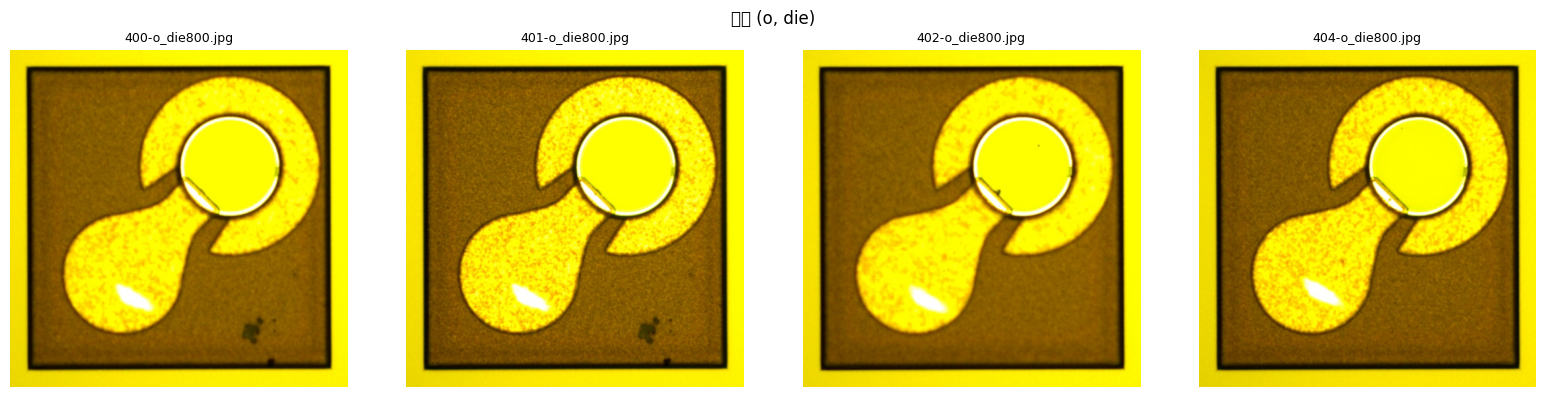

/tmp/ipykernel_624/46147549.py:18: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_624/46147549.py:18: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


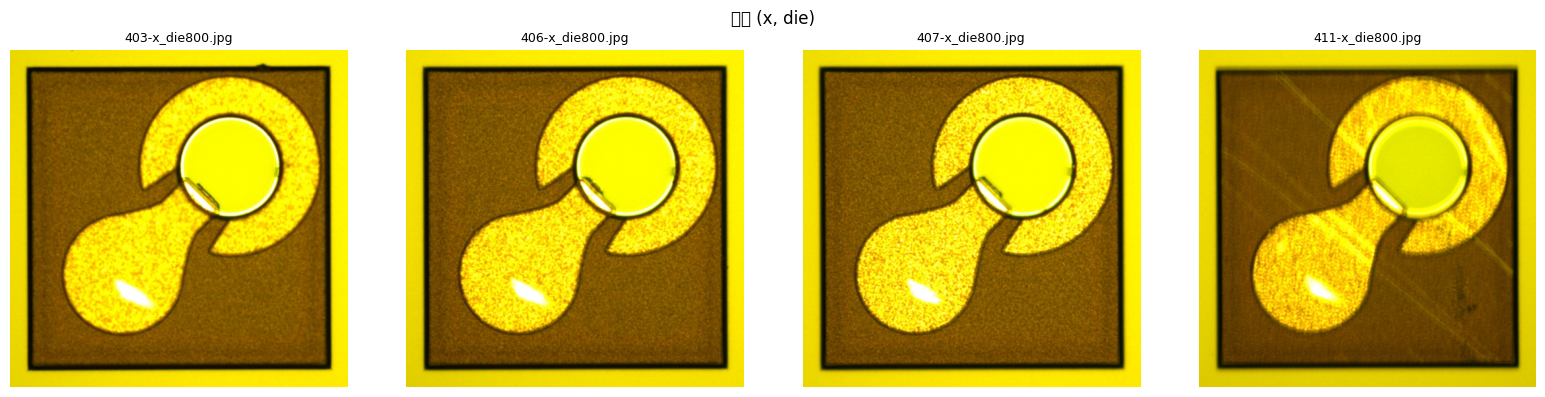

In [15]:
import sys
import importlib # Add this line to import importlib

sys.path.insert(0, "/content/Phosem-CNN-Problem-Detection")
importlib.invalidate_caches() # Invalidate import caches
from data_loader import load_image_gpu, load_batch_gpu, scan_dataset

def show_row(paths, title, n=4):
    n = min(n, len(paths))
    if n == 0:
        print(f"{title}: 없음"); return
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    axes = [axes] if n == 1 else axes
    for ax, p in zip(axes, paths[:n]):
        t, _ = load_image_gpu(p)
        ax.imshow(t[0].permute(1, 2, 0).cpu().numpy())
        ax.set_title(os.path.basename(p), fontsize=9); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_row(good_paths, "양품 (o, die)")
show_row(bad_paths,  "불량 (x, die)")

In [16]:
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

IMG_SIZE = 256
class DieDataset(Dataset):
    def __init__(self, paths, labels, train=True):
        self.paths, self.labels = paths, labels
        if train:
            self.tf = T.Compose([
                T.Resize((IMG_SIZE, IMG_SIZE)),
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
                T.RandomRotation(10),
                T.ColorJitter(brightness=0.2, contrast=0.2),
                T.ToTensor(),
            ])
        else:
            self.tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])

    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tf(img), self.labels[i]

all_paths  = good_paths + bad_paths
all_labels = [0]*len(good_paths) + [1]*len(bad_paths)

idx = list(range(len(all_paths)))
random.seed(42); random.shuffle(idx)
split = int(len(idx)*0.8)
tr_idx, va_idx = idx[:split], idx[split:]

train_ds = DieDataset([all_paths[i] for i in tr_idx], [all_labels[i] for i in tr_idx], train=True)
val_ds   = DieDataset([all_paths[i] for i in va_idx], [all_labels[i] for i in va_idx], train=False)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=8)

print(f"학습 {len(train_ds)}장 / 검증 {len(val_ds)}장")
print(f"검증 세트 불량 비율: {sum(all_labels[i] for i in va_idx)}/{len(va_idx)}")

학습 13장 / 검증 4장
검증 세트 불량 비율: 1/4


In [18]:
import torch.nn as nn

def build_cnn(channels=[16, 32, 64], num_classes=2, in_size=IMG_SIZE):
    """channels 리스트 = 각 conv층 채널 수. 리스트 길이 = 층수(깊이)"""
    layers, in_ch = [], 3
    for out_ch in channels:
        layers += [
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        ]
        in_ch = out_ch
    layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(in_ch, num_classes)]
    return nn.Sequential(*layers)

model = build_cnn([16, 32, 64, 128]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"파라미터 수: {n_params:,}")

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplac

In [19]:
def train_model(model, train_dl, val_dl, epochs=30, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best_acc, history = 0, []

    for ep in range(1, epochs+1):
        model.train(); tr_loss = 0
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step()
            tr_loss += loss.item() * len(x)

        # 검증
        model.eval(); correct = total = 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                correct += (model(x).argmax(1) == y).sum().item()
                total += len(x)
        acc = correct / total
        history.append((tr_loss/len(train_dl.dataset), acc))
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_classifier.pth")
        print(f"epoch {ep:2d} | loss {history[-1][0]:.4f} | val acc {acc:.3f}"
              + (" *" if acc == best_acc else ""))

    print(f"\n최고 검증 정확도: {best_acc:.3f} → best_classifier.pth 저장됨")
    return history

history = train_model(model, train_dl, val_dl)

epoch  1 | loss 0.6939 | val acc 0.250 *
epoch  2 | loss 0.8109 | val acc 0.250 *
epoch  3 | loss 0.4590 | val acc 0.750 *
epoch  4 | loss 0.6837 | val acc 0.750 *
epoch  5 | loss 0.4503 | val acc 0.750 *
epoch  6 | loss 0.3971 | val acc 0.750 *
epoch  7 | loss 0.4231 | val acc 0.750 *
epoch  8 | loss 0.6079 | val acc 0.750 *
epoch  9 | loss 0.6436 | val acc 0.750 *
epoch 10 | loss 0.4865 | val acc 0.750 *
epoch 11 | loss 0.4593 | val acc 0.750 *
epoch 12 | loss 0.5496 | val acc 0.750 *
epoch 13 | loss 0.7511 | val acc 0.750 *
epoch 14 | loss 0.5926 | val acc 0.750 *
epoch 15 | loss 0.4457 | val acc 0.750 *
epoch 16 | loss 0.4941 | val acc 0.250
epoch 17 | loss 0.4898 | val acc 0.250
epoch 18 | loss 0.5544 | val acc 0.250
epoch 19 | loss 0.5331 | val acc 0.750 *
epoch 20 | loss 0.4203 | val acc 0.750 *
epoch 21 | loss 0.5483 | val acc 0.750 *
epoch 22 | loss 0.5714 | val acc 0.750 *
epoch 23 | loss 0.5486 | val acc 0.750 *
epoch 24 | loss 0.4966 | val acc 1.000 *
epoch 25 | loss 0.6031

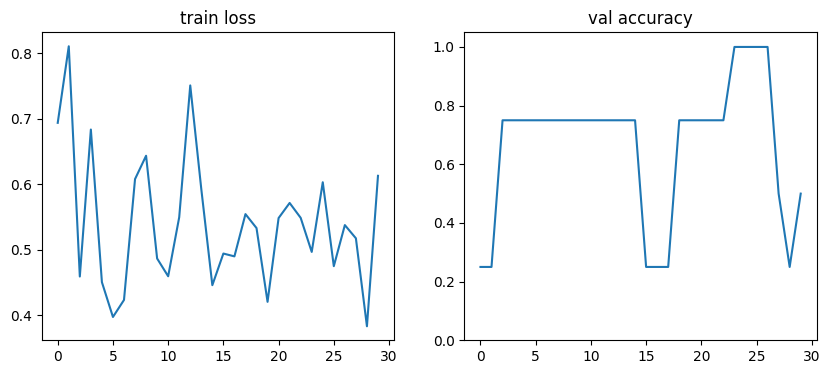

파일                                       정답   예측   불량확률
405-o_die800.jpg                         양품   양품   0.33
411-x_die800.jpg                         불량   불량   0.52
400-o_die800.jpg                         양품   양품   0.25
404-o_die800.jpg                         양품   양품   0.31


In [20]:
losses, accs = zip(*history)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(losses); ax[0].set_title("train loss")
ax[1].plot(accs); ax[1].set_title("val accuracy"); ax[1].set_ylim(0, 1.05)
plt.show()

# 검증 이미지별 판정 결과
model.load_state_dict(torch.load("best_classifier.pth"))
model.eval()
print(f"{'파일':40s} 정답   예측   불량확률")
with torch.no_grad():
    for i in va_idx:
        x = val_ds.tf(Image.open(all_paths[i]).convert("RGB")).unsqueeze(0).to(DEVICE)
        prob = torch.softmax(model(x), 1)[0, 1].item()
        gt, pred = ["양품","불량"][all_labels[i]], ["양품","불량"][prob > 0.5]
        mark = "" if gt == pred else "  ← 오답"
        print(f"{os.path.basename(all_paths[i]):40s} {gt}   {pred}   {prob:.2f}{mark}")

In [21]:
import pandas as pd
import numpy as np

model.load_state_dict(torch.load("best_classifier.pth"))
model.eval()

rows = []
with torch.no_grad():
    for i in va_idx:
        x = val_ds.tf(Image.open(all_paths[i]).convert("RGB")).unsqueeze(0).to(DEVICE)
        prob = torch.softmax(model(x), 1)[0, 1].item()
        rows.append({
            "파일": os.path.basename(all_paths[i]),
            "정답": ["양품", "불량"][all_labels[i]],
            "예측": ["양품", "불량"][int(prob > 0.5)],
            "불량확률": round(prob, 3),
            "판정": "O" if (prob > 0.5) == bool(all_labels[i]) else "X",
        })

df = pd.DataFrame(rows).sort_values("불량확률", ascending=False).reset_index(drop=True)
display(df)

cm = pd.crosstab(df["정답"], df["예측"], rownames=["정답"], colnames=["예측"])
display(cm)

tp = len(df[(df.정답=="불량") & (df.예측=="불량")])
fn = len(df[(df.정답=="불량") & (df.예측=="양품")])
fp = len(df[(df.정답=="양품") & (df.예측=="불량")])
tn = len(df[(df.정답=="양품") & (df.예측=="양품")])

summary = pd.DataFrame({
    "지표": ["정확도", "불량 검출률 (recall)", "불량 예측 정밀도 (precision)", "과검률 (양품→불량 오판)"],
    "값": [
        f"{(tp+tn)/len(df):.1%}",
        f"{tp/(tp+fn):.1%}" if tp+fn else "-",
        f"{tp/(tp+fp):.1%}" if tp+fp else "-",
        f"{fp/(fp+tn):.1%}" if fp+tn else "-",
    ],
})
display(summary)

,파일,정답,예측,불량확률,판정
0,411-x_die800.jpg,불량,불량,0.516,O
1,405-o_die800.jpg,양품,양품,0.325,O
2,404-o_die800.jpg,양품,양품,0.315,O
3,400-o_die800.jpg,양품,양품,0.251,O


예측,불량,양품
정답,,
불량,1,0
양품,0,3


,지표,값
0,정확도,100.0%
1,불량 검출률 (recall),100.0%
2,불량 예측 정밀도 (precision),100.0%
3,과검률 (양품→불량 오판),0.0%
